**Phase 1 – Dataset Collection**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [3]:
df = pd.read_csv("V3.csv")
df

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,Waterbury,111440.0,185000,Single Family,Detached House,3,3,996.0,1.025953,South
1,1/2/2009,2009,NaN,73080.0,152000,Single Family,Detached House,3,1,935.0,1.025953,North
2,1/2/2009,2009,Waterbury,50540.0,105000,Single Family,Detached House,3,1,951.0,1.025953,East
3,1/2/2009,2009,Norwalk,571060.0,1000000,Single Family,Detached House,3,2,NaN,1.025953,South
4,1/2/2009,2009,Bridgeport,4775276.0,272900,Single Family,Detached House,3,1,971.0,1.025953,East
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9/30/2022,2022,NaN,155550.0,215000,Three Family,Triplex,6,5,2114.0,1.003979,North
9996,9/30/2022,2022,Greenwich,NaN,2162500,Single Family,Detached House,3,3,933.0,1.003979,North
9997,9/30/2022,2022,West Hartford,124740.0,225635,Single Family,Detached House,3,1,922.0,1.003979,North
9998,9/30/2022,2022,NaN,1455230.0,2625000,Single Family,Detached House,3,2,977.0,1.003979,North


In [4]:
df.head()

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,Waterbury,111440.0,185000,Single Family,Detached House,3,3,996.0,1.025953,South
1,1/2/2009,2009,NaN,73080.0,152000,Single Family,Detached House,3,1,935.0,1.025953,North
2,1/2/2009,2009,Waterbury,50540.0,105000,Single Family,Detached House,3,1,951.0,1.025953,East
3,1/2/2009,2009,Norwalk,571060.0,1000000,Single Family,Detached House,3,2,NaN,1.025953,South
4,1/2/2009,2009,Bridgeport,4775276.0,272900,Single Family,Detached House,3,1,971.0,1.025953,East


In [5]:
df.shape

(10000, 12)

In [6]:
df.columns

Index(['Date', 'Year', 'Locality', 'Estimated Value', 'Sale Price', 'Property',
       'Residential', 'num_rooms', 'num_bathrooms', 'carpet_area',
       'property_tax_rate', 'Face'],
      dtype='object')

****Phase 2 – Exploratory Data Analysis (EDA)****

Step 1 Missing Value Analysis

In [7]:
df.isnull().sum()

Date                    0
Year                    0
Locality             1255
Estimated Value      1229
Sale Price              0
Property                0
Residential             0
num_rooms               0
num_bathrooms           0
carpet_area          1282
property_tax_rate       0
Face                    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               10000 non-null  object 
 1   Year               10000 non-null  int64  
 2   Locality           8745 non-null   object 
 3   Estimated Value    8771 non-null   float64
 4   Sale Price         10000 non-null  int64  
 5   Property           10000 non-null  object 
 6   Residential        10000 non-null  object 
 7   num_rooms          10000 non-null  int64  
 8   num_bathrooms      10000 non-null  int64  
 9   carpet_area        8718 non-null   float64
 10  property_tax_rate  10000 non-null  float64
 11  Face               10000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 937.6+ KB


In [9]:
df['carpet_area'].fillna(df['carpet_area'].mean(), inplace=True)
df['Locality'].fillna(df['Locality'].mode()[0], inplace=True)
df["Estimated Value"].fillna(df["Estimated Value"].mean(), inplace=True)
df

C:\Users\admin\AppData\Local\Temp\ipykernel_14252\3901084338.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['carpet_area'].fillna(df['carpet_area'].mean(), inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_14252\3901084338.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,Waterbury,1.114400e+05,185000,Single Family,Detached House,3,3,996.000000,1.025953,South
1,1/2/2009,2009,Bridgeport,7.308000e+04,152000,Single Family,Detached House,3,1,935.000000,1.025953,North
2,1/2/2009,2009,Waterbury,5.054000e+04,105000,Single Family,Detached House,3,1,951.000000,1.025953,East
3,1/2/2009,2009,Norwalk,5.710600e+05,1000000,Single Family,Detached House,3,2,1111.658981,1.025953,South
4,1/2/2009,2009,Bridgeport,4.775276e+06,272900,Single Family,Detached House,3,1,971.000000,1.025953,East
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9/30/2022,2022,Bridgeport,1.555500e+05,215000,Three Family,Triplex,6,5,2114.000000,1.003979,North
9996,9/30/2022,2022,Greenwich,4.445842e+05,2162500,Single Family,Detached House,3,3,933.000000,1.003979,North
9997,9/30/2022,2022,West Hartford,1.247400e+05,225635,Single Family,Detached House,3,1,922.000000,1.003979,North
9998,9/30/2022,2022,Bridgeport,1.455230e+06,2625000,Single Family,Detached House,3,2,977.000000,1.003979,North


In [10]:
# Replace ? with NaN
df['Property'] = df['Property'].replace('?', np.nan)

# Fill missing values with Unknown
df['Property'].fillna('Unknown', inplace=True)
df

C:\Users\admin\AppData\Local\Temp\ipykernel_14252\196623895.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Property'].fillna('Unknown', inplace=True)


,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,Waterbury,1.114400e+05,185000,Single Family,Detached House,3,3,996.000000,1.025953,South
1,1/2/2009,2009,Bridgeport,7.308000e+04,152000,Single Family,Detached House,3,1,935.000000,1.025953,North
2,1/2/2009,2009,Waterbury,5.054000e+04,105000,Single Family,Detached House,3,1,951.000000,1.025953,East
3,1/2/2009,2009,Norwalk,5.710600e+05,1000000,Single Family,Detached House,3,2,1111.658981,1.025953,South
4,1/2/2009,2009,Bridgeport,4.775276e+06,272900,Single Family,Detached House,3,1,971.000000,1.025953,East
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9/30/2022,2022,Bridgeport,1.555500e+05,215000,Three Family,Triplex,6,5,2114.000000,1.003979,North
9996,9/30/2022,2022,Greenwich,4.445842e+05,2162500,Single Family,Detached House,3,3,933.000000,1.003979,North
9997,9/30/2022,2022,West Hartford,1.247400e+05,225635,Single Family,Detached House,3,1,922.000000,1.003979,North
9998,9/30/2022,2022,Bridgeport,1.455230e+06,2625000,Single Family,Detached House,3,2,977.000000,1.003979,North


Step 2 Duplicate Values

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

Step 3 Statistical Summary

In [13]:
df.describe()

,Year,Estimated Value,Sale Price,num_rooms,num_bathrooms,carpet_area,property_tax_rate
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,2015.880100,4.445842e+05,6.224748e+05,3.329600,2.334000,1111.658981,1.143517
std,4.088031,7.036676e+05,1.029709e+06,0.885123,1.209293,284.831689,0.166762
min,2009.000000,0.000000e+00,2.000000e+03,3.000000,1.000000,900.000000,1.003979
25%,2012.000000,1.420500e+05,1.600000e+05,3.000000,1.000000,969.000000,1.023495
50%,2016.000000,2.808150e+05,3.400000e+05,3.000000,2.000000,1038.000000,1.025899
75%,2019.000000,4.445842e+05,6.300000e+05,3.000000,3.000000,1111.658981,1.348259
max,2022.000000,2.111991e+07,2.575000e+07,8.000000,8.000000,2989.000000,1.422308


In [14]:
df['Estimated Value'] = df['Estimated Value'].astype(int)
df.head()

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,Waterbury,111440,185000,Single Family,Detached House,3,3,996.000000,1.025953,South
1,1/2/2009,2009,Bridgeport,73080,152000,Single Family,Detached House,3,1,935.000000,1.025953,North
2,1/2/2009,2009,Waterbury,50540,105000,Single Family,Detached House,3,1,951.000000,1.025953,East
3,1/2/2009,2009,Norwalk,571060,1000000,Single Family,Detached House,3,2,1111.658981,1.025953,South
4,1/2/2009,2009,Bridgeport,4775276,272900,Single Family,Detached House,3,1,971.000000,1.025953,East


Step 4 Outlier Analysis

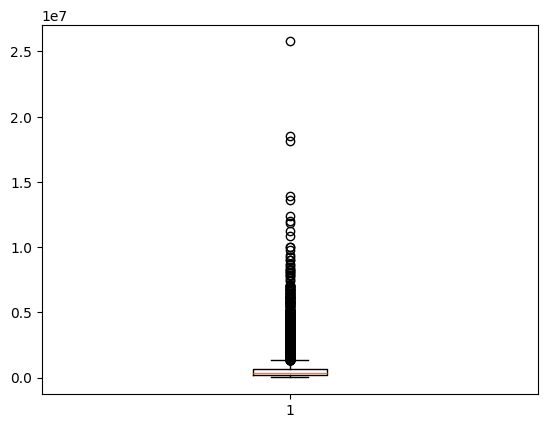

In [15]:
plt.boxplot(df["Sale Price"])
plt.show()

In [16]:
# Display all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(num_cols)

Index(['Year', 'Estimated Value', 'Sale Price', 'num_rooms', 'num_bathrooms',
       'carpet_area', 'property_tax_rate'],
      dtype='object')


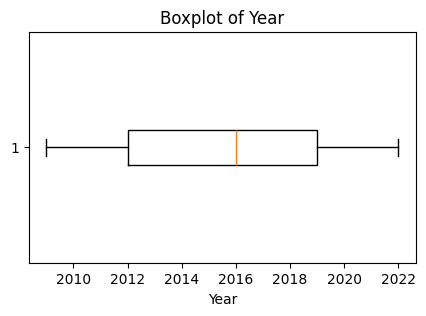

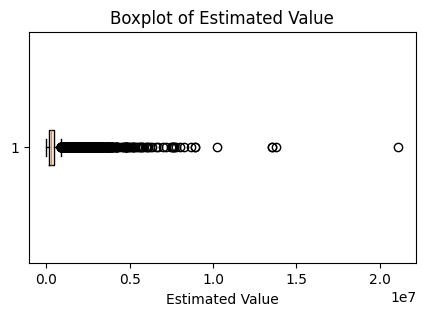

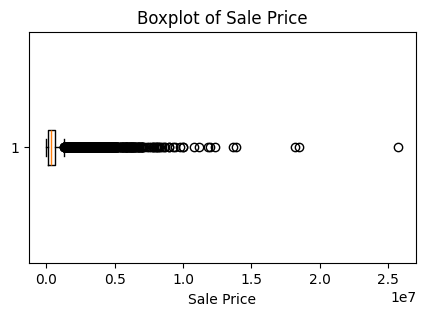

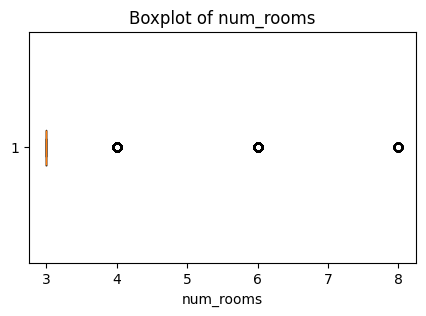

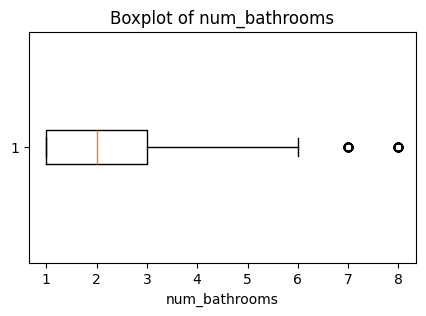

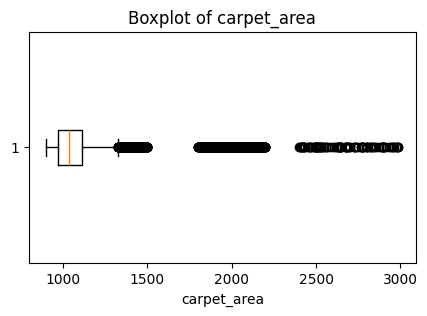

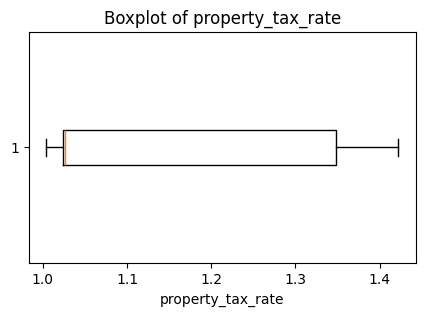

In [17]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [18]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Year: 0 outliers
Estimated Value: 912 outliers
Sale Price: 1011 outliers
num_rooms: 1704 outliers
num_bathrooms: 70 outliers
carpet_area: 1132 outliers
property_tax_rate: 0 outliers


In [19]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append([col, count])

import pandas as pd

outlier_df = pd.DataFrame(outlier_summary,
                          columns=["Column", "Outlier Count"])

print(outlier_df)

              Column  Outlier Count
0               Year              0
1    Estimated Value            912
2         Sale Price           1011
3          num_rooms           1704
4      num_bathrooms             70
5        carpet_area           1132
6  property_tax_rate              0


In [20]:
df2 = df.copy()

columns_to_clean = [
    "Estimated Value",
    "Sale Price",
    "carpet_area",
    "property_tax_rate"
]

for col in columns_to_clean:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df2 = df2[
        (df2[col] >= lower) &
        (df2[col] <= upper)
    ]

print(df.shape)
print(df2.shape)

(10000, 12)
(7547, 12)


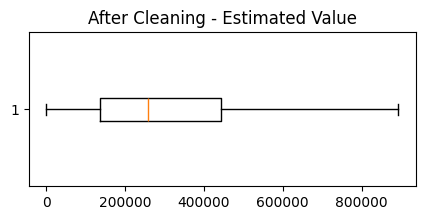

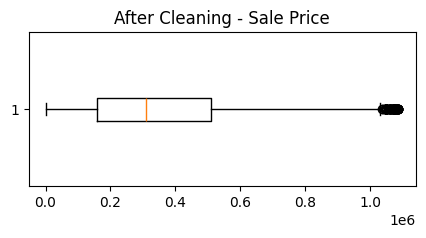

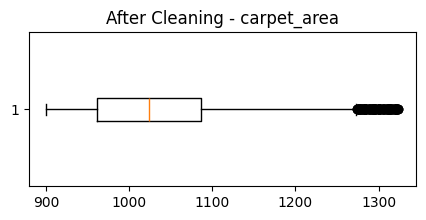

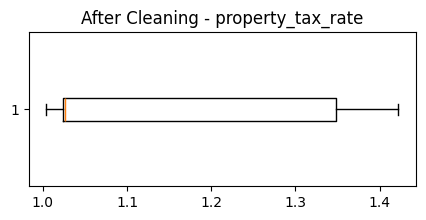

In [21]:
for col in columns_to_clean:
    plt.figure(figsize=(5,2))
    plt.boxplot(df2[col], vert=False)
    plt.title(f"After Cleaning - {col}")
    plt.show()

**Step 5 Correlation Analysis**

In [22]:
corr = df2.select_dtypes(include='number').corr()

corr

,Year,Estimated Value,Sale Price,num_rooms,num_bathrooms,carpet_area,property_tax_rate
Year,1.000000,-0.019114,0.045805,-0.012246,-0.021822,0.005207,0.028364
Estimated Value,-0.019114,1.000000,0.774237,-0.103929,-0.038693,-0.069314,-0.018277
Sale Price,0.045805,0.774237,1.000000,-0.137250,-0.063115,-0.076612,-0.035281
num_rooms,-0.012246,-0.103929,-0.137250,1.000000,0.461951,0.430892,-0.017957
num_bathrooms,-0.021822,-0.038693,-0.063115,0.461951,1.000000,0.204557,-0.013055
carpet_area,0.005207,-0.069314,-0.076612,0.430892,0.204557,1.000000,-0.026567
property_tax_rate,0.028364,-0.018277,-0.035281,-0.017957,-0.013055,-0.026567,1.000000


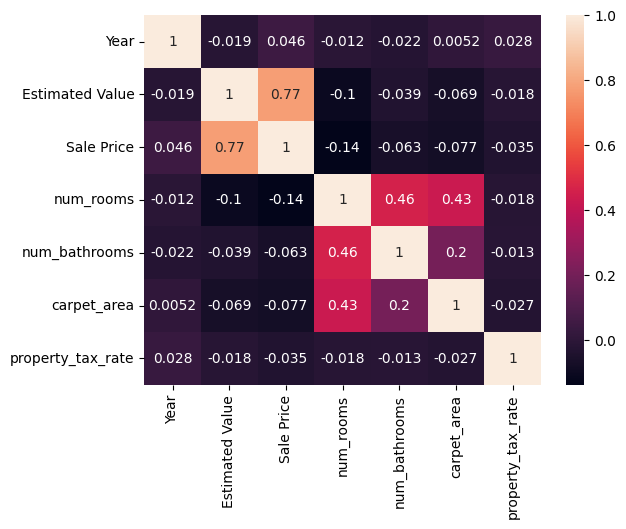

In [23]:
import seaborn as sns

sns.heatmap(corr,annot=True)
plt.show()

**Step 6 Visualization**

<Axes: >

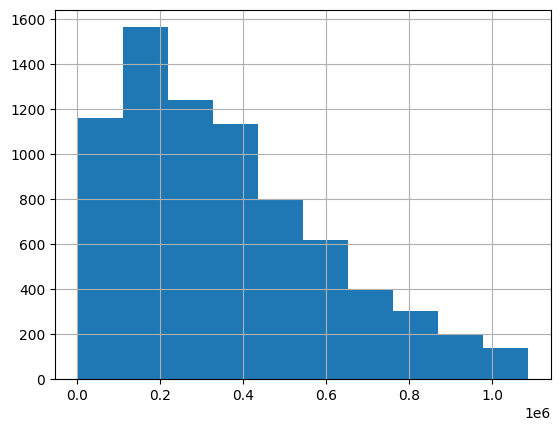

In [24]:
df2["Sale Price"].hist()

<Axes: xlabel='Property'>

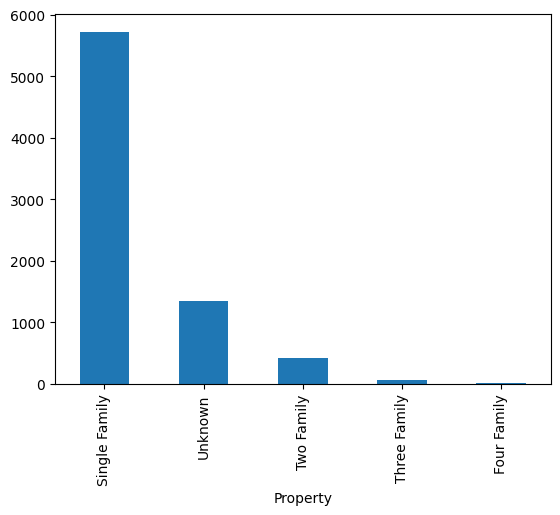

In [25]:
df2["Property"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

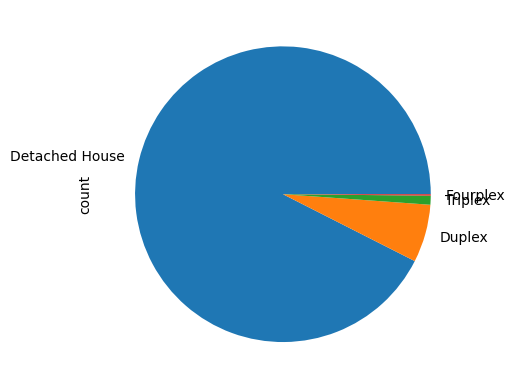

In [26]:
df2["Residential"].value_counts().plot(kind="pie")

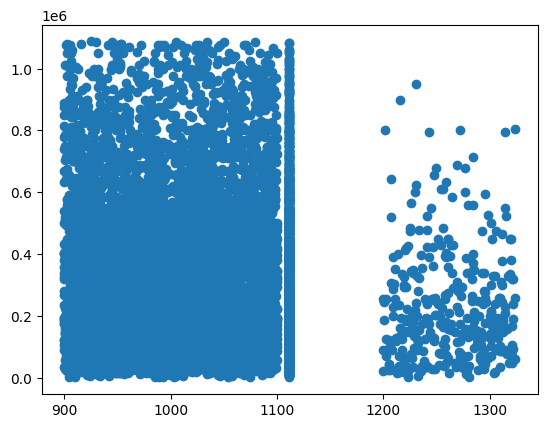

In [27]:
plt.scatter(df2["carpet_area"],df2["Sale Price"])

{'whiskers': [<matplotlib.lines.Line2D at 0x1765abedf90>,
 'caps': [<matplotlib.lines.Line2D at 0x1765abee210>,
 'boxes': [<matplotlib.lines.Line2D at 0x1765abede50>],
 'medians': [<matplotlib.lines.Line2D at 0x1765abee490>],
 'fliers': [<matplotlib.lines.Line2D at 0x1765abee5d0>],
 'means': []}

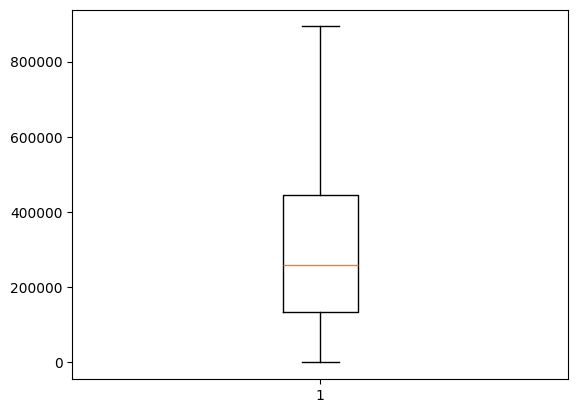

In [28]:
plt.boxplot(df2["Estimated Value"])

# **Phase 3 – Data Preprocessing**

**Step 1 Encoding**

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df2["Property"] = le.fit_transform(df2["Property"])

df2["Residential"] = le.fit_transform(df2["Residential"])

df2["Face"] = le.fit_transform(df2["Face"])

df2["Locality"] = le.fit_transform(df2["Locality"])

df2

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face
0,1/2/2009,2009,5,111440,185000,1,0,3,3,996.000000,1.025953,2
1,1/2/2009,2009,0,73080,152000,1,0,3,1,935.000000,1.025953,1
2,1/2/2009,2009,5,50540,105000,1,0,3,1,951.000000,1.025953,0
3,1/2/2009,2009,3,571060,1000000,1,0,3,2,1111.658981,1.025953,2
7,1/3/2009,2009,3,172620,409000,4,0,3,3,1004.000000,1.025953,2
...,...,...,...,...,...,...,...,...,...,...,...,...
9991,9/30/2022,2022,3,154920,196000,1,0,3,1,932.000000,1.003979,0
9992,9/30/2022,2022,1,181020,340000,1,0,3,2,916.000000,1.003979,0
9994,9/30/2022,2022,0,216420,415000,1,0,3,3,1014.000000,1.003979,1
9997,9/30/2022,2022,6,124740,225635,1,0,3,1,922.000000,1.003979,1


**Step 2 Feature Engineering**

In [30]:
df2["Property_Tier"] = pd.qcut(
    df["Sale Price"],
    q=3,
    labels=["Low","Medium","High"]
)
df2

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face,Property_Tier
0,1/2/2009,2009,5,111440,185000,1,0,3,3,996.000000,1.025953,2,Low
1,1/2/2009,2009,0,73080,152000,1,0,3,1,935.000000,1.025953,1,Low
2,1/2/2009,2009,5,50540,105000,1,0,3,1,951.000000,1.025953,0,Low
3,1/2/2009,2009,3,571060,1000000,1,0,3,2,1111.658981,1.025953,2,High
7,1/3/2009,2009,3,172620,409000,4,0,3,3,1004.000000,1.025953,2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,9/30/2022,2022,3,154920,196000,1,0,3,1,932.000000,1.003979,0,Low
9992,9/30/2022,2022,1,181020,340000,1,0,3,2,916.000000,1.003979,0,Medium
9994,9/30/2022,2022,0,216420,415000,1,0,3,3,1014.000000,1.003979,1,Medium
9997,9/30/2022,2022,6,124740,225635,1,0,3,1,922.000000,1.003979,1,Medium


**Step 3 Scaling**

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num = ["Estimated Value",
       "Sale Price",
       "num_rooms",
       "num_bathrooms",
       "carpet_area",
       "property_tax_rate"]

df2[num] = scaler.fit_transform(df2[num])
df2

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_rooms,num_bathrooms,carpet_area,property_tax_rate,Face,Property_Tier
0,1/2/2009,2009,5,-1.017036,-0.702523,1,0,-0.236575,0.970823,-0.381705,-0.712403,2,Low
1,1/2/2009,2009,0,-1.241172,-0.835721,1,0,-0.236575,-1.192071,-1.112313,-0.712403,1,Low
2,1/2/2009,2009,5,-1.372873,-1.025429,1,0,-0.236575,-1.192071,-0.920678,-0.712403,0,Low
3,1/2/2009,2009,3,1.668513,2.587082,1,0,-0.236575,-0.110624,1.003564,-0.712403,2,High
7,1/3/2009,2009,3,-0.659562,0.201614,4,0,-0.236575,0.970823,-0.285887,-0.712403,2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,9/30/2022,2022,3,-0.762983,-0.658123,1,0,-0.236575,-1.192071,-1.148245,-0.843275,0,Low
9992,9/30/2022,2022,1,-0.610481,-0.076892,1,0,-0.236575,-0.110624,-1.339880,-0.843275,0,Medium
9994,9/30/2022,2022,0,-0.403640,0.225832,1,0,-0.236575,0.970823,-0.166116,-0.843275,1,Medium
9997,9/30/2022,2022,6,-0.939324,-0.538507,1,0,-0.236575,-1.192071,-1.268017,-0.843275,1,Medium


# **Phase 4 – Model Development**

**Step 1 Select Features**

In [32]:
df2["Date"] = pd.to_datetime(df2["Date"])

df2["Day"] = df2["Date"].dt.day
df2["Month"] = df2["Date"].dt.month
df2["Year"] = df2["Date"].dt.year

df2.drop("Date", axis=1, inplace=True)

In [33]:
X = df2.drop("Property_Tier",axis=1)

y = df2["Property_Tier"]

**Step 2 Train-Test Split**

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Model 1 Decision Tree**

In [35]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [36]:
pred = model.predict(X_test)

# **Model 2 SVM**

In [37]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train,y_train)

pred2 = svm.predict(X_test)

# **Phase 5 – Performance Evaluation**

In [38]:
from sklearn.metrics import accuracy_score

new_var = accuracy_score(y_test, pred)

new_var

1.0

In [39]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred2)

0.38079470198675497

In [40]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,pred)


array([[379,   0,   0],
       [  0, 556,   0],
       [  0,   0, 575]])

In [41]:
confusion_matrix(y_test,pred2)

array([[  0,   0, 379],
       [  0,   0, 556],
       [  0,   0, 575]])

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       379
         Low       1.00      1.00      1.00       556
      Medium       1.00      1.00      1.00       575

    accuracy                           1.00      1510
   macro avg       1.00      1.00      1.00      1510
weighted avg       1.00      1.00      1.00      1510



In [43]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

        High       0.00      0.00      0.00       379
         Low       0.00      0.00      0.00       556
      Medium       0.38      1.00      0.55       575

    accuracy                           0.38      1510
   macro avg       0.13      0.33      0.18      1510
weighted avg       0.15      0.38      0.21      1510



c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

in above code we compre the models

# **Phase 6 – Model Saving**

In [44]:
import joblib

joblib.dump(model,"real_estate_model.pkl")

['real_estate_model.pkl']

In [45]:
model = joblib.load("real_estate_model.pkl")

# **Phase 7 – Streamlit Deployment**

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np


categorical_cols = ['Locality', 'Property', 'Residential', 'Face']
label_encoders = {}


for col in categorical_cols:
    le = LabelEncoder()

    label_encoders[col] = le.fit(df[col])

sample_input = {
    'Year': 2020,
    'Locality': 'Waterbury',
    'Estimated Value': 200000.0,
    'Sale Price': 300000,
    'Property': 'Single Family',
    'Residential': 'Detached House',
    'num_rooms': 4,
    'num_bathrooms': 2,
    'carpet_area': 1200.0,
    'property_tax_rate': 1.05,
    'Face': 'South',
    'Day': 15,
    'Month': 6
}

input_df = pd.DataFrame([sample_input])

for col in categorical_cols:
    input_df[col] = label_encoders[col].transform(input_df[col])

numerical_cols_to_scale_for_prediction = [
    "Estimated Value", "Sale Price", "num_rooms", "num_bathrooms",
    "carpet_area", "property_tax_rate"
]
input_df[numerical_cols_to_scale_for_prediction] = scaler.transform(input_df[numerical_cols_to_scale_for_prediction])


expected_columns = X.columns.tolist()

input_df = input_df[expected_columns]

predicted_tier_encoded = model.predict(input_df)

predicted_tier = predicted_tier_encoded[0]

print(f"Predicted Property Tier: {predicted_tier}")

Predicted Property Tier: Medium


In [47]:
import joblib

# Save model (you already have this)
joblib.dump(model, "real_estate_model.pkl")

# ALSO save the encoders and scaler so the app can reuse them
joblib.dump(label_encoders, "label_encoders.pkl")   # dict of LabelEncoders per column
joblib.dump(scaler, "scaler.pkl")                    # the StandardScaler you fit

['scaler.pkl']